#Orchestration with Airflow

##Objective: Automate model lifecycle with Airflow DAGs for training triggers.

###1. Step-by-Step Guide:
- Set up Airflow DAG (mlops_dag.py): Define tasks for train, version, evaluate, deploy.

###2. Trigger Mechanisms:
- API Trigger: Expose Airflow REST API; use curl to trigger DAG.
- Scheduled/Drift-Triggered: Use sensors to check for drift (e.g., monitor data stats).

### 3. DAG Structure:
- Task 1: Pull data (if drift detected via custom operator checking stats).
- Task 2: Run training in container (use KubernetesPodOperator: from airflow.providers.cncf.kubernetes.operators.kubernetes import
KubernetesPodOperator; train_task = KubernetesPodOperator(image='iris-training:latest', ...)).

- Task 3: Version and store in S3 via MLflow.
- Task 4: If better, deploy; else, retrain (branching with BranchPythonOperator).

### 4. Drift Handling:

Custom operator compares data distributions (e.g., KS test); if drift > threshold, trigger DAG and notify (use EmailOperator: email_task = EmailOperator(to='dev@example.com', subject='Drift Detected')).
Hands-On: Run Airflow, trigger DAG manually, simulate drift.


```
[Data Drift Check] → [Train in Container] → [Version Model in MLflow/S3]
                         ↓
             [Branch: Deploy if better, else Skip]
```



### 1. Set up Airflow DAG (mlops_dag.py)
Define the tasks in your DAG:

- Train Model

- Version Model

- Evaluate Model

- Deploy Model

# 1. Train Model

**Purpose:**

To build the machine learning model using the available dataset.

Converts raw data into a trained model capable of making predictions.

**Key Steps (Theoretical):**

- Data Preparation: Clean, preprocess, and transform the dataset.

- Model Selection: Choose an appropriate algorithm (e.g., Random Forest, Neural Network).

- Training: Fit the model on the training data.

- Output: A trained model artifact ready for evaluation.

**Importance in DAG:**

This is the first critical step. All downstream tasks (versioning, evaluation, deployment) depend on successful training.


In [ ]:
# Simple Concept Example
def train_model():
    print("Training model...")

def version_model():
    print("Versioning model...")

def evaluate_model():
    print("Evaluating model...")

# Simulate DAG flow
train_model()
version_model()
evaluate_model()

# 2. Trigger Mechanisms:
### i) API Trigger:
Airflow provides a REST API that allows external systems to programmatically trigger DAG executions.

Useful for event-driven or on-demand ML workflows, where training or evaluation should start based on specific conditions outside of Airflow.

### Expose Airflow REST API:

Each DAG can be triggered via a unique API endpoint.

```
# Trigger DAG run via Airflow REST API
curl -X POST "http://<airflow_host>:8080/api/v1/dags/<dag_id>/dagRuns" \
     -H "Content-Type: application/json" \
     -d '{"conf": {"param1": "value1", "param2": "value2"}}'
```

**Explanation:**

- ```http://<airflow_host>:8080``` → Airflow webserver URL

- ```<dag_id>``` → Unique identifier for the DAG to trigger

- dagRuns → API resource for creating a new DAG run

- conf → Optional JSON parameters passed to the DAG for dynamic configuration

### ii) Use of  Curl to trigger DAG
```
curl -X POST "http://<airflow_host>:8080/api/v1/dags/<dag_id>/dagRuns" \
     -H "Content-Type: application/json" \
     -d '{"conf": {}}'
```




### iii) Scheduled/Drift-Triggered:
**Use sensors to check for drift (e.g., monitor data stats).**
In Airflow, a sensor is a special operator that waits for a certain condition to be met before moving to the next task. For data drift, we can create a custom sensor that:

- Collects statistics (mean, variance, distribution) from the incoming data.
- Compares these with the reference training data stats.
- If the difference exceeds a threshold, drift is considered detected.
- The sensor then triggers retraining tasks in the DAG.



## Scheduled Trigger (Standard Cron)
#### Airflow will run the DAG daily at 6 AM, no manual intervention.

In [ ]:

with DAG(
    dag_id="mlops_pipeline",
    schedule_interval="0 6 * * *",  # every day at 6 AM
    start_date=days_ago(1),
    catchup=False,
) as dag:
    ...


## Drift-Triggered (Custom Sensor Operator)

### This is where real MLOps comes in → you don’t want to retrain blindly, you retrain when data drift is detected.

**Example: Custom Drift Sensor**

In [ ]:
from airflow.sensors.base import BaseSensorOperator
import pandas as pd
from scipy.stats import ks_2samp

class DataDriftSensor(BaseSensorOperator):
    def poke(self, context):
        """
        Check if new data distribution has drifted compared to reference.
        If drift > threshold, return True (trigger downstream tasks).
        """
        # Load reference data (production baseline)
        reference = pd.read_csv("/opt/ml/reference_data.csv")["feature"]

        # Load latest batch (e.g., from data lake)
        latest = pd.read_csv("/opt/ml/latest_data.csv")["feature"]

        # Kolmogorov-Smirnov Test
        stat, p_value = ks_2samp(reference, latest)
        print(f"Drift p-value: {p_value}")

        # If p-value < 0.05 → significant drift
        return p_value < 0.05


**Example Conceptual Workflow**

1. Sensor Task → Runs a drift check (e.g., using KS-Test, PSI, or simple mean comparison).

2. If drift detected → Continue with tasks: Train → Version → Evaluate → Deploy

3. If no drift → End DAG or send a notification.

### Key Conceptual Takeaways

1. API Trigger: Enables on-demand, external control over DAG execution.

2. Scheduled Trigger: Ensures routine and predictable execution for ML pipelines.

3. Drift-Triggered: Enables adaptive, intelligent workflows that respond to real-world data changes, keeping models up-to-date.

# 3. DAG Structure:

Task 1: Pull data (if drift detected via custom operator checking stats).

Task 2: Run training in container (use KubernetesPodOperator: from airflow.providers.cncf.kubernetes.operators.kubernetes import KubernetesPodOperator; train_task = KubernetesPodOperator(image='iris-training:latest', ...)).

Task 3: Version and store in S3 via MLflow.

Task 4: If better, deploy; else, retrain (branching with BranchPythonOperator).

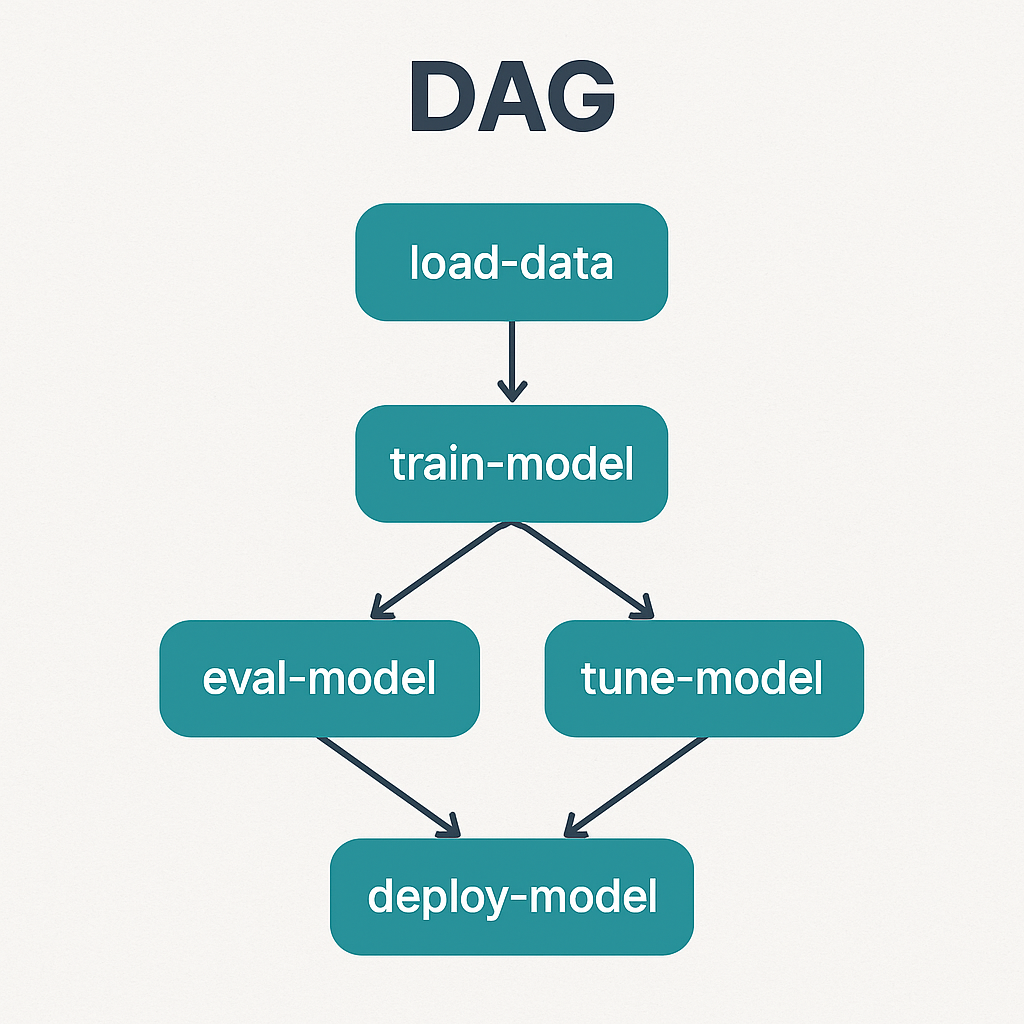

# DAG Structure (Conceptual)
### Task 1: Pull Data & Check Drift

A custom operator/sensor checks for data drift by comparing the latest dataset with the reference training data.

If drift > threshold → Proceed with training.

If no drift → DAG can stop or send a notification.

### Task 2: Run Training in Container

Uses KubernetesPodOperator to launch a training job inside a containerized environment.

Example: A Docker image (iris-training:latest) that contains the ML training code.

Ensures scalability and isolation — every training run is reproducible.

### Task 3: Version and Store Model

i) After training, the model is logged and versioned in MLflow.

ii)The model artifact is pushed to S3 (or any object storage).

iii) Keeps track of:

- Model parameters

- Training metrics

- Version numbers

iv) Enables experiment tracking and rollback to older versions.

### Task 4: Deploy (Conditional)

A Branching Operator (BranchPythonOperator) decides whether the new model is better than the old one.

If better: Deploy model to production (e.g., update endpoint, replace container).

If not: Skip deployment and return to monitoring loop (or retrain with different settings).

```
Visual Flow(Conceptual)

[Task 1: Check Drift]
        ↓ (if drift detected)
[Task 2: Train in Container]
        ↓
[Task 3: Version & Store Model in S3/MLflow]
        ↓
[Task 4: Branch → Deploy if better, else Retrain/Stop]

```



# Demo Code on DAG

In [ ]:
from airflow import DAG
from airflow.operators.python import PythonOperator, BranchPythonOperator
from airflow.providers.cncf.kubernetes.operators.kubernetes import KubernetesPodOperator
from airflow.utils.dates import days_ago
import mlflow
import boto3
import random

# -----------------------
# Drift Detection Function
# -----------------------
def check_drift(**context):
    """
    Dummy drift detection logic: In real-world,
    compare data stats with reference stats (KS-test, PSI, etc.)
    """
    drift_detected = random.choice([True, False])  # demo random
    print(f"Drift Detected: {drift_detected}")
    return "train_model" if drift_detected else "no_retrain_needed"

# -----------------------
# Model Evaluation Function
# -----------------------
def evaluate_model(**context):
    """
    Compare latest trained model with production using MLflow metrics.
    If new model is better, return 'deploy_model', else 'retrain_model'.
    """
    # Demo: Random decision, real-world: compare accuracy, F1, AUC etc.
    better = random.choice([True, False])
    print(f"New model better: {better}")
    return "deploy_model" if better else "retrain_model"

# -----------------------
# Deploy Model Function
# -----------------------
def deploy_model(**context):
    """
    Push model from MLflow Registry to production endpoint (SageMaker, Docker, etc.)
    """
    print("Deploying the model to production...")

def no_retrain_needed(**context):
    print("No drift detected. Skipping retrain.")


# -----------------------
# DAG Definition
# -----------------------
with DAG(
    dag_id="mlops_drift_pipeline",
    default_args={"owner": "airflow"},
    schedule_interval="@daily",
    start_date=days_ago(1),
    catchup=False,
) as dag:

    # 1️⃣ Drift Detection
    drift_task = BranchPythonOperator(
        task_id="check_drift",
        python_callable=check_drift,
        provide_context=True,
    )

    # 2️⃣ Train Model in Kubernetes Pod
    train_task = KubernetesPodOperator(
        task_id="train_model",
        name="iris-training",
        namespace="airflow",
        image="iris-training:latest",
        cmds=["python", "train.py"],  # inside container
        is_delete_operator_pod=True,
    )

    # Dummy skip path
    skip_task = PythonOperator(
        task_id="no_retrain_needed",
        python_callable=no_retrain_needed,
    )

    # 3️⃣ Register Model in MLflow / Store in S3
    version_task = PythonOperator(
        task_id="register_model",
        python_callable=lambda **kwargs: print("Registering model in MLflow + S3"),
    )

    # 4️⃣ Evaluate & Decide Deploy or Retrain
    eval_task = BranchPythonOperator(
        task_id="evaluate_model",
        python_callable=evaluate_model,
    )

    # If better → Deploy
    deploy_task = PythonOperator(
        task_id="deploy_model",
        python_callable=deploy_model,
    )

    # If not better → Retrain (loop back)
    retrain_task = PythonOperator(
        task_id="retrain_model",
        python_callable=lambda: print("Retraining again..."),
    )

    # -----------------------
    # DAG Dependencies
    # -----------------------
    drift_task >> [train_task, skip_task]
    train_task >> version_task >> eval_task
    eval_task >> [deploy_task, retrain_task]


# 4. Drift Handling

**Custom operator compares data distributions (e.g., KS test);**

**if drift > threshold, trigger DAG and notify (use EmailOperator: email_task = EmailOperator(to='dev@example.com', subject='Drift Detected')).**

**Hands-On: Run Airflow, trigger DAG manually, simulate drift.**

### Define Custom Drift Check Operator
- We’ll use Kolmogorov–Smirnov (KS) test to compare reference vs new data distributions.

In [ ]:
from airflow.sensors.base import BaseSensorOperator
import pandas as pd
from scipy.stats import ks_2samp

class DataDriftSensor(BaseSensorOperator):
    """
    Custom sensor that checks if data drift is significant.
    If KS-test p-value < threshold → drift detected.
    """
    def __init__(self, reference_path, latest_path, threshold=0.05, **kwargs):
        super().__init__(**kwargs)
        self.reference_path = reference_path
        self.latest_path = latest_path
        self.threshold = threshold

    def poke(self, context):
        # Load datasets
        reference = pd.read_csv(self.reference_path)["feature"]
        latest = pd.read_csv(self.latest_path)["feature"]

        # Compare distributions
        stat, p_value = ks_2samp(reference, latest)
        print(f"KS Test p-value={p_value}")

        # Return True if drift detected
        return p_value < self.threshold


In [ ]:
# Define Drift Notification Task

# We notify the team if drift is detected.

from airflow.operators.email import EmailOperator

notify_drift = EmailOperator(
    task_id="notify_drift",
    to="dev@example.com",
    subject="⚠️ Drift Detected",
    html_content="<p>Data drift was detected. Retraining pipeline started.</p>"
)


   ```
    Visual Flow of Custom Drift Handling
          ┌────────────────────┐
          │  New Batch Arrives │
          └─────────┬──────────┘
                    │
                    ▼
          ┌────────────────────┐
          │ Data Drift Sensor  │
          │ (KS test, p-value) │
          └─────────┬──────────┘
                    │
        ┌───────────┴───────────┐
   Drift Detected           No Drift
         │                      │
         ▼                      ▼
 ┌────────────────────┐   ┌──────────────────┐
 │ Send Notification  │   │ Continue Normal  │
 │ (Email/Slack/Etc.) │   │   Monitoring     │
 └─────────┬──────────┘   └──────────────────┘
           │
           ▼
 ┌────────────────────┐
 │  Retrain Model     │
 │ (Airflow Task)     │
 └─────────┬──────────┘
           │
           ▼
 ┌────────────────────┐
 │  Evaluate Model    │
 │ (Metrics check)    │
 └─────────┬──────────┘
           │
   ┌───────┴────────┐
Better Model    Worse Model
      │                 │
      ▼                 ▼
┌─────────────┐   ┌─────────────┐
│ Deploy New  │   │ Keep Current│
│   Model     │   │   Model     │
└─────────────┘   └─────────────┘
```

